In [1]:
import pickle
import numpy as np

with open(f"../log/insight_student_embeddings_val_epoch{4}.pkl", "rb") as f:
    minusface_data = pickle.load(f)

In [2]:
with open(f"../../attacks/partialface/log/insight_student_embeddings_val_epoch{4}.pkl", "rb") as f:
    partialface_data = pickle.load(f)

In [3]:
with open(f"./log/insight_student_embeddings_val_epoch{4}.pkl", "rb") as f:
    fracface_data = pickle.load(f)

In [4]:
partialface_data['filenames'] = sum(partialface_data['filenames'], [])
minusface_data['filenames'] = sum(minusface_data['filenames'], [])
fracface_data["filenames"] = sum(fracface_data["filenames"], []) 

In [5]:
import torch
minusface_data['student_embeddings'] = torch.cat(minusface_data['student_embeddings'], dim=0)
partialface_data['student_embeddings'] = torch.cat(partialface_data['student_embeddings'], dim=0)
fracface_data['student_embeddings'] = torch.cat(fracface_data['student_embeddings'], dim=0)


In [6]:
minusface_data["teacher_embeddings"] = torch.cat(minusface_data["teacher_embeddings"], dim=0)
partialface_data["teacher_embeddings"] = torch.cat(partialface_data["teacher_embeddings"], dim=0)
fracface_data["teacher_embeddings"] = torch.cat(fracface_data["teacher_embeddings"], dim=0)

In [7]:
np.all(np.array(minusface_data['filenames']) == np.array(partialface_data['filenames']))

np.False_

In [8]:
set(minusface_data['filenames']) - set(partialface_data['filenames']), set(partialface_data['filenames']) - set(minusface_data['filenames'])


(set(), set())

In [9]:
torch.nn.functional.cosine_similarity(minusface_data["teacher_embeddings"][0][0], partialface_data["student_embeddings"][0], dim=0)

tensor(-0.0120)

In [10]:
import os
minusface_embeddings = {}
partialface_embeddings = {}
teacher_embeddings = {}
fracface_embeddings = {} 

for i, fname in enumerate(minusface_data['filenames']): # cannot sort because embeddings did nots ort
    id = fname.split("/")[-2] 
    # print(id)
    old = minusface_embeddings.get(id, [])
    old.append((minusface_data['student_embeddings'][i].cpu().numpy(), fname))
    old_teacher = teacher_embeddings.get(id, [])
    old_teacher.append((minusface_data['teacher_embeddings'][i].cpu().numpy(), fname))
    teacher_embeddings[id] = old_teacher
    minusface_embeddings[id] = old

for i, fname in enumerate(partialface_data['filenames']):
    id = fname.split("/")[-2]
    old = partialface_embeddings.get(id, [])
    old.append((partialface_data['student_embeddings'][i].cpu().numpy(), fname))
    partialface_embeddings[id] = old 

for i, fname in enumerate(fracface_data['filenames']):
    id = fname.split("/")[-2]
    old = fracface_embeddings.get(id, [])
    old.append((fracface_data['student_embeddings'][i].cpu().numpy(), fname))
    fracface_embeddings[id] = old 

In [11]:
len(minusface_embeddings) 

2115

In [12]:

# import tqdm
# pre_loaded_teachers = {}
# root = '/path/to/casia-webface'
# val_paths = []
# root = '/path/to/casia-webface'
# with open("./index.txt","r") as f:
#     lines = f.readlines()
#     for line in lines:
#         filename, split = line.strip().split()
#         if split != "train":
#             val_paths.append(os.path.join(root, filename)) 
        
# embedding_root = '/path/to/casia-webface/insight_embeddings'

# import pickle
# for path in tqdm.tqdm(val_paths, desc="Preloading embeddings"):
#     embedding = np.load(embedding_root+"/"+path.replace("/path/to/casia-webface/","").replace("/", "_").replace(".jpg", ".npy"))[None,:]
#     pre_loaded_teachers[path] = torch.from_numpy(embedding).float()



In [13]:
minusface_embeddings_1 = [v[0][0] for k, v in sorted(minusface_embeddings.items())]
minusface_embeddings_2 = [v[1][0] for k, v in sorted(minusface_embeddings.items())]
partialface_embeddings_1 = [v[0][0] for k, v in sorted(partialface_embeddings.items())]
partialface_embeddings_2 = [v[1][0] for k, v in sorted(partialface_embeddings.items())]
teacher_embeddings_1 = [v[0][0] for k, v in sorted(teacher_embeddings.items())]
teacher_embeddings_2 = [v[1][0] for k, v in sorted(teacher_embeddings.items())]
fracface_embeddings_1 = [v[0][0] for k, v in sorted(fracface_embeddings.items())]
fracface_embeddings_2 = [v[1][0] for k, v in sorted(fracface_embeddings.items())]
assert len(minusface_embeddings_1) == len(partialface_embeddings_2) == len(minusface_embeddings_2) == len(partialface_embeddings_1) == len(teacher_embeddings_1) == len(teacher_embeddings_2)

In [14]:
a = partialface_embeddings["000299"][0][0]
a = a / np.linalg.norm(a) 
b = teacher_embeddings["000299"][0][0][0]
b = b / np.linalg.norm(b)
np.dot(a, b), a.shape, b.shape 

(np.float32(0.8364833), (512,), (512,))

In [15]:
partialface_embeddings.keys()

dict_keys(['005599', '009437', '006239', '001435', '000299', '008042', '002458', '001588', '000084', '004974', '000190', '008899', '006729', '005586', '004399', '004559', '002290', '004542', '002643', '009222', '001560', '007516', '009951', '010504', '000175', '000612', '000631', '008689', '000162', '009370', '008883', '009695', '004215', '008722', '009644', '005240', '007037', '006837', '010343', '010496', '004066', '006278', '007807', '006834', '001383', '004420', '009417', '000839', '007120', '009363', '007111', '009781', '006814', '009394', '000710', '006316', '006143', '004263', '009709', '002088', '008205', '008934', '009835', '008457', '004635', '008428', '007956', '000740', '005286', '005588', '000475', '000124', '008008', '007090', '002510', '002897', '004853', '008295', '001375', '007739', '005255', '008796', '000421', '001889', '000370', '007838', '003346', '003665', '010035', '009083', '009236', '006161', '002578', '005781', '003133', '008219', '009126', '001029', '002515',

In [16]:
# torch.nn.functional.cosine_similarity(
#     partialface_data["student_embeddings"][partialface_data["filenames"].index("/path/to/casia-webface/000000/00000001.jpg")][None],
#     minusface_data["student_embeddings"][minusface_data["filenames"].index("/path/to/casia-webface/000000/00000002.jpg")][None],
# )

In [17]:
a = minusface_embeddings["000000"][0][1]
b = minusface_embeddings["000000"][1][1]
a, b

('/path/to/casia-webface/000000/00000009.jpg',
 '/path/to/casia-webface/000000/00000005.jpg')

In [18]:
# torch.nn.functional.cosine_similarity(pre_loaded_teachers[a], pre_loaded_teachers[b])

In [19]:
type(teacher_embeddings_1)

list

In [20]:
minusface_embeddings_1 = minusface_embeddings_1 / np.linalg.norm(minusface_embeddings_1, axis=-1, keepdims=True)
partialface_embeddings_2 = partialface_embeddings_2 / np.linalg.norm(partialface_embeddings_2, axis=-1, keepdims=True)
minusface_embeddings_2 = minusface_embeddings_2 / np.linalg.norm(minusface_embeddings_2, axis=-1, keepdims=True)
partialface_embeddings_1 = partialface_embeddings_1 / np.linalg.norm(partialface_embeddings_1, axis=-1, keepdims=True)
teacher_embeddings_1 = teacher_embeddings_1 / np.linalg.norm(teacher_embeddings_1, axis=-1, keepdims=True)
teacher_embeddings_2 = teacher_embeddings_2 / np.linalg.norm(teacher_embeddings_2, axis=-1, keepdims=True)
fracface_embeddings_1 = fracface_embeddings_1 / np.linalg.norm(fracface_embeddings_1, axis=-1, keepdims=True)
fracface_embeddings_2 = fracface_embeddings_2 / np.linalg.norm(fracface_embeddings_2, axis=-1, keepdims=True)

In [21]:
teacher_embeddings_1 = teacher_embeddings_1[:,0]
teacher_embeddings_2 = teacher_embeddings_2[:,0]

In [22]:
len(teacher_embeddings_1)

2115

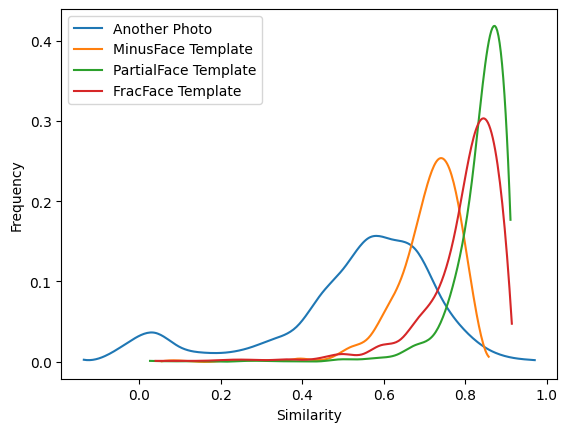

In [23]:
from scipy.interpolate import make_interp_spline, BSpline

sims_teachers = np.diagonal(((teacher_embeddings_1 @ teacher_embeddings_2.T)))
# sims_teachers = sims_teachers[sims_teachers>0.2]
sim_teacher_minusface = np.diagonal(((teacher_embeddings_1 @ minusface_embeddings_1.T)))
sim_teacher_partial = np.diagonal(((teacher_embeddings_1 @ partialface_embeddings_1.T)))
sim_teacher_fracface = np.diagonal(((teacher_embeddings_1 @ fracface_embeddings_1.T)))
import matplotlib.pyplot as plt
 
import numpy as np
import matplotlib.pyplot as plt

def plot(data, label):
    counts, bin_edges = np.histogram(data, bins=20)
    prob = counts / counts.sum()
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    xnew = np.linspace(bin_centers.min(), bin_centers.max(), 300)  
    spl = make_interp_spline(bin_centers, prob)
    prob_smooth = spl(xnew)
    plt.plot(xnew, prob_smooth, label=label)

plot(sims_teachers, "Another Photo")
plot(sim_teacher_minusface, "MinusFace Template")
plot(sim_teacher_partial, "PartialFace Template") 
plot(sim_teacher_fracface, "FracFace Template")

plt.xlabel("Similarity")
plt.ylabel("Frequency")
plt.legend()
plt.show() 


In [24]:
# np.where(sims_teachers < 0.2)

In [25]:
# import cv2
# from insightface.app import FaceAnalysis
# import torch

# app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
# app.prepare(ctx_id=0, det_size=(160, 160))


# def compare_face_insight(img1, img2):
#     try:
#         image = np.array(img1.convert("RGB"))
#         faces = app.get(image)
#         faceid_embeds_1 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
#         image = np.array(img2.convert("RGB"))
#         faces = app.get(image)
#         faceid_embeds_2 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
#         cos_sim = torch.nn.functional.cosine_similarity(faceid_embeds_1, faceid_embeds_2).item()
#         return cos_sim
#     except Exception as e:
#         print("Error in compare_face_insight:", e)
#         return None


In [26]:
# teacher_embeddings.keys()

In [27]:
# from PIL import Image
# compare_face_insight(Image.open(minusface_embeddings["005599"][1][1]),
#                         Image.open(teacher_embeddings["005599"][6][1])) 

In [28]:
# sims = []
# for id in minusface_embeddings.keys():
#     if len(teacher_embeddings[id]) < 2:
#         continue
#     face1 = minusface_embeddings[id][0][1]
#     face2 = teacher_embeddings[id][1][1]
#     sim = compare_face_insight(Image.open(face1), Image.open(face2))
#     if sim is not None:
#         sims.append(sim)
#     print(np.mean(sims), np.mean([i for i in sims if i>0.3]))


In [29]:
minusface_embeddings_1.shape

(2115, 512)

In [30]:

sources = ["minusface_embeddings_1", "teacher_embeddings_1", "partialface_embeddings_1", "fracface_embeddings_1"]
targets = ["minusface_embeddings_2", "teacher_embeddings_2", "partialface_embeddings_2", "fracface_embeddings_2"]

mapping = {
    "minusface_embeddings_1": minusface_embeddings_1,
    "teacher_embeddings_1": teacher_embeddings_1,
    "partialface_embeddings_1": partialface_embeddings_1,
    "minusface_embeddings_2": minusface_embeddings_2,
    "teacher_embeddings_2": teacher_embeddings_2,
    "partialface_embeddings_2": partialface_embeddings_2, 
    "fracface_embeddings_1": fracface_embeddings_1,
    "fracface_embeddings_2": fracface_embeddings_2,}
    
data = []

for source in sources:
    for target in targets:
        source_embeddings_1 = mapping[source]
        target_embeddings_2 = mapping[target]
        ranks = []
        for i in range(len(minusface_embeddings_1)):
            query = source_embeddings_1[i] 
            keys = target_embeddings_2
            sims = np.dot(keys, query)  
            ranks.append(len(sims) - (np.where(np.argsort(sims) == i)[0][0])) 
        data.append({
            "source": f"{source}".split('=')[0],
            "target": f"{target}".split('=')[0],
            "mean_rank": np.mean(ranks)/len(sims),
            "top1_recall": np.mean(np.array(ranks)==1),
            "top_5_recall": np.mean(np.array(ranks)<=5),
        })

In [34]:
df

,source,target,mean_rank,top1_recall,top_5_recall
0,Minusface_Embeddings_1,Minusface_Embeddings_2,0.050673,0.720567,0.801891
1,Minusface_Embeddings_1,Teacher_Embeddings_2,0.046028,0.813239,0.855319
2,Minusface_Embeddings_1,Partialface_Embeddings_2,0.047650,0.775414,0.825532
3,Minusface_Embeddings_1,Fracface_Embeddings_2,0.050483,0.730496,0.801891
4,Teacher_Embeddings_1,Minusface_Embeddings_2,0.048641,0.824113,0.859574
5,Teacher_Embeddings_1,Teacher_Embeddings_2,0.045293,0.882270,0.893144
6,Teacher_Embeddings_1,Partialface_Embeddings_2,0.046507,0.856265,0.880851
7,Teacher_Embeddings_1,Fracface_Embeddings_2,0.047949,0.844444,0.869976
8,Partialface_Embeddings_1,Minusface_Embeddings_2,0.047561,0.786761,0.835934
9,Partialface_Embeddings_1,Teacher_Embeddings_2,0.043862,0.857210,0.879905


In [35]:
import pandas as pd
df = pd.DataFrame(data)
df.source = df.source.str.title()
df.target = df.target.str.title()
df2 = df.pivot(index='source', columns='target', values='top1_recall')
df2

target,Fracface_Embeddings_2,Minusface_Embeddings_2,Partialface_Embeddings_2,Teacher_Embeddings_2
source,,,,
Fracface_Embeddings_1,0.786288,0.753664,0.813712,0.847754
Minusface_Embeddings_1,0.730496,0.720567,0.775414,0.813239
Partialface_Embeddings_1,0.802837,0.786761,0.826950,0.857210
Teacher_Embeddings_1,0.844444,0.824113,0.856265,0.882270


In [36]:

print(df2.to_latex(float_format="%.4f", index=True, caption="Linkage Results between MinusFace, PartialFace, and Teacher Embeddings", label="tab:linkage_results").replace("_", " ").replace("Embeddings 1", "").replace("Embeddings 2", "").replace("Teacher", "Original Image"))

\begin{table}
\caption{Linkage Results between MinusFace, PartialFace, and Original Image Embeddings}
\label{tab:linkage results}
\begin{tabular}{lrrrr}
\toprule
target & Fracface  & Minusface  & Partialface  & Original Image  \\
source &  &  &  &  \\
\midrule
Fracface  & 0.7863 & 0.7537 & 0.8137 & 0.8478 \\
Minusface  & 0.7305 & 0.7206 & 0.7754 & 0.8132 \\
Partialface  & 0.8028 & 0.7868 & 0.8270 & 0.8572 \\
Original Image  & 0.8444 & 0.8241 & 0.8563 & 0.8823 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
# import cv2
# from insightface.app import FaceAnalysis
# import torch

# app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
# app.prepare(ctx_id=0, det_size=(160, 160))



# def compare_face_insight(img1, img2):
#     try:
#         image = np.array(img1.convert("RGB"))[:,:,::-1]
#         faces = app.get(image)
#         faceid_embeds_1 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
#         image = np.array(img2.convert("RGB"))[:,:,::-1]
#         faces = app.get(image)
#         faceid_embeds_2 = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
#         cos_sim = torch.nn.functional.cosine_similarity(faceid_embeds_1, faceid_embeds_2).item()
#         return cos_sim
#     except Exception as e:
#         print("Error in compare_face_insight:", e)
#         return None

In [ ]:
# import os
# ids = os.listdir("/path/to/casia-webface/")

In [ ]:
# from PIL import Image
# sims = []
# for id in ids:
#     faces = os.listdir(f"/path/to/casia-webface/{id}/")
#     selected_faces = faces[:2]
#     res = compare_face_insight(Image.open(f"/path/to/casia-webface/{id}/{selected_faces[0]}"), Image.open(f"/path/to/casia-webface/{id}/{selected_faces[1]}"))
#     if res is not None:
#         if res > 0.3:
#             sims.append(res)
#     print(sum(sims)/len(sims), end="\r", flush=True)